# CODE TO CREATE SUPPORT AND CORE BY TOPONYM ACCORDING RATIO VALUE ON ROADS

    # IMPORT LIBRARY

In [1]:
#import lib

import pandas as pd
import geopandas as gpd
import fiona 
import alphashape
from scipy.spatial import ConvexHull
import ogr 
import shapely
import matplotlib.pyplot as plt
import shapefile
from collections import OrderedDict
from pyproj import Transformer
from geopandas import GeoDataFrame
from shapely.geometry import Point
import pickle
import numpy as np 


import alphashape
import networkx as nx
import copy
import momepy

c:\users\ablanchi\appdata\local\programs\python\python36\lib\site-packages\geopandas\_compat.py:110: UserWarning: The Shapely GEOS version (3.8.0-CAPI-1.13.1 ) is incompatible with the GEOS version PyGEOS was compiled with (3.10.1-CAPI-1.16.0). Conversions between both will be slow.
  shapely_geos_version, geos_capi_version_string


In [2]:
import pandas as pd 
import geopandas as gpd
import shapely.speedups
shapely.speedups.enable() 
import fiona 
import alphashape
from scipy.spatial import ConvexHull
import ogr 
import shapely
import matplotlib.pyplot as plt
import shapefile
from collections import OrderedDict
from pyproj import Transformer
from geopandas import GeoDataFrame
from shapely.geometry import Point
import geopandas as gpd
from shapely.ops import unary_union
from shapely.geometry import Point

    # FUNCTIONS TO DETECT SUPPORT AND CORE ACCORDING TOPONYM VALUE ON STREETS

In [3]:
#function to extract subgraph of space

def extract_support_as_subgraph(TOPONYME, value ):
    # Transform into float values
    for u, v, d in G.edges(data=True):
        d[TOPONYME] = float(d.get(TOPONYME))
    # Extraction of link according conditions
    edges = [(u, v, d) for u, v, d in G.edges(data=True) if d.get(TOPONYME) >= value]
    # Create subgraph
    subgraph = nx.Graph(edges)
    node_ids = list(subgraph.nodes())
    subgraph = G.subgraph(node_ids)
    subgraph = nx.Graph(subgraph)
    print(">> Size of subgraph by toponym == ", len(subgraph))
    return subgraph

In [4]:
#function to add neighbors

def add_neighbors(G, my_subgraph, iterations):
    subgraph_dilated = copy.deepcopy(my_subgraph)
    # ITERATIONS
    for i in range(iterations):
       # Add neighbors
        end_nodes = [n for n, d in subgraph_dilated.degree() if d <= 1]
        for node in end_nodes:
            first_neighbors = [n for n in nx.neighbors(G, node) if n not in subgraph.nodes()] ##subgrah_dilated_nodes??
            for first_neighbor in first_neighbors:
                    subgraph_dilated.add_edge(node, first_neighbor) 
    node_ids = list(subgraph_dilated.nodes())
    subgraph_dilated = G.subgraph(node_ids)
    subgraph_dilated = nx.Graph(subgraph_dilated)
    print(">> Size of Subgraph after operations of DILATATION == ", len(subgraph_dilated))
    return subgraph_dilated

In [5]:
#function to add neighbors FOR core space

def add_neighbors_core(G, my_subgraph, iterations):
    subgraph_dilated = copy.deepcopy(my_subgraph)
    # ACCORDING ITERATIONS
    for i in range(iterations):
       # FIRST NEIGHBORS ON SUBGRAPH
        end_nodes = [n for n, d in subgraph_dilated.degree() if d <= 1]
        for node in end_nodes:
            first_neighbors = [n for n in nx.neighbors(G, node) if n not in subgraph_dilated.nodes()]
            for first_neighbor in first_neighbors:
                    subgraph_dilated.add_edge(node, first_neighbor) 
    node_ids = list(subgraph_dilated.nodes())
    subgraph_dilated = G.subgraph(node_ids)
    subgraph_dilated = nx.Graph(subgraph_dilated)
    print(">> Size of Subgraph after operations of DILATATION == ", len(subgraph_dilated))
    return subgraph_dilated

In [6]:
#FUNCTION TO REMOVE NEIGHBORS

def remove_neighbors(G, subgraph, iterations):
    subgraph_rem = copy.deepcopy(subgraph)
    for i in range(iterations):
        # Obtenir la liste des sommets avec un degré inférieur ou égal à 1 et supprimer du sousgraph
        leaves = [n for n, d in subgraph_rem.degree() if d <= 1]
        subgraph_rem.remove_nodes_from(leaves)
    node_ids = list(subgraph_rem.nodes())
    subgraph_dilated = G.subgraph(node_ids)
    subgraph_dilated = nx.Graph(subgraph_dilated)
    print(">> Size of subgraph after operations of EROSION == ", len(subgraph_dilated))
    return subgraph_rem

In [7]:
#FUNCTION TO EXTRACT COMPONENTS

def extract_components_by_size(G, my_subgraph, min_size_of_components):
    subgraph_opened_cc = copy.deepcopy(my_subgraph)
    # Get all the connected components
    components = list(nx.connected_components(subgraph_opened_cc))
    # Sort components by size
    components = sorted(components, key=len, reverse=True) # or reverse=False for croissant.
    # Itération sur les composantes et suppression des composantes inférieures au seuil
    print("Size of all components from Subgraph  == ", [len(c) for c in components])
    for component in components:
        if len(component) < min_size_of_components:
            subgraph_opened_cc.remove_nodes_from(component)
    node_ids = list(subgraph_opened_cc.nodes())
    subgraph_opened_cc = G.subgraph(node_ids)
    subgraph_opened_cc = nx.Graph(subgraph_opened_cc)
    print("Len of Subgraph after the extraction of firstly components == ", len(subgraph_opened_cc))
    return subgraph_opened_cc

In [8]:
def extract_first_component(G, my_subgraph):
    subgraph_opened_cc = copy.deepcopy(my_subgraph)
    # Get all the connected components
    components = list(nx.connected_components(subgraph_opened_cc))
    components = sorted(components, key=len, reverse=True) # or reverse=False for croissant.
    print("Size of all components from Subgraph  == ", [len(c) for c in components])
    #Extract largest cc 
    largest_cc = max(nx.connected_components(subgraph_opened_cc), key=len)
    subgraph_opened_cc = G.subgraph(largest_cc)
    subgraph_opened_cc = nx.Graph(subgraph_opened_cc)
    print("Len of Subgraph after the extraction of the first cc == ", len(subgraph_opened_cc))
    return subgraph_opened_cc

In [9]:
#function to extract core from support

def extract_core_from_support(G, my_subgraph, TOPONYME, quantile):
    nodes, edges = momepy.nx_to_gdf(my_subgraph)
    # Calculez le pourcentile de la variable
    threshold = edges[TOPONYME].quantile(quantile) #0.9 pour 10%
    # Sélectionnez les lignes où la variable est supérieure au seuil
    if threshold < 0.5:
        subset_df = edges[edges[TOPONYME] > threshold]
        print("Minimum of quantile value == ", min(list(subset_df[TOPONYME])))
    else : 
        subset_df = edges[edges[TOPONYME] > 0.5]
    print("-- Len of subset == ", len(subset_df))
    
    list_floats = [float(i) for i in list(set(subset_df['lineID'].tolist()))] ## BECAUSE ID IS FLOAT IN G 
    selected_edges = [(u,v) for u,v,data in G.edges(data=True) if data['lineID'] in list_floats]
    print('-- Len of Selected Edges in G == ',len(selected_edges))
    
    #CREATE SUBGRAPH 
    FG = nx.Graph(selected_edges)
    subgraph_quantile = G.subgraph(FG.nodes())
    subgraph_quantile = nx.Graph(subgraph_quantile)
    nx.is_frozen(subgraph_quantile)
    
    return subgraph_quantile

In [10]:
#function to extract support as subgraph

def extract_support_as_subgraph(TOPONYME, value ):
    # Transform into float values
    for u, v, d in G.edges(data=True):
        d[TOPONYME] = float(d.get(TOPONYME))
    # Extract links according conditions
    edges = [(u, v, d) for u, v, d in G.edges(data=True) if d.get(TOPONYME) >= value]
    # Create subgraph
    subgraph = nx.Graph(edges)
    node_ids = list(subgraph.nodes())
    subgraph = G.subgraph(node_ids)
    subgraph = nx.Graph(subgraph)
    print(">> Size of subgraph by toponym == ", len(subgraph))
    return subgraph

    # APPLYING FUNCTIONS TO CREATE SUPPORT AND CORE BY TOPONYM

In [11]:
### SAUVEGARDE AS LIST 

def applying_functions(TOPONYME, SIZE):
    #CREATION OF SUPPORT ACCORIDNG TOPONYM VALUE IN SUPPORT CREATED  
    subgraph = extract_support_as_subgraph(TOPONYME, 0.1)
    print('subgraph')
    subgraph_dil = add_neighbors_core(G, subgraph, SIZE)
    print('subgraph_dil')
    subgraph_ero = remove_neighbors(G, subgraph_dil, SIZE)
    print('subgraph_ero')
    support_end = extract_first_component(G, subgraph_ero ) ## Or change function if you want selected by size
    print("support_end")

    #CREATION OF CORE ACCORDING TOPONYM VALUE IN SUPPORT CREATED
    quantile_subgraph = extract_core_from_support(G, support_end, TOPONYME, 0.9)
    quantile_subgraph_dil = add_neighbors_core(G, quantile_subgraph, SIZE)## Or change function if you want selected by size
    quantile_subgraph_ero=  remove_neighbors(G, quantile_subgraph_dil, SIZE)
    core_end = extract_first_component(G, quantile_subgraph_ero )
    #core_end = remove_neighbors(G, quantile_subgraph_dil, SIZE)
    print('_____________________')
    print('ATTENTION == Le noyau est composé de composantes connexes :',  [len(c) for c in list(nx.connected_components(core_end))])



       ## transform
    support_end_nodes, support_end_edges = momepy.nx_to_gdf(support_end)
    core_end_nodes, core_end_edges = momepy.nx_to_gdf(core_end)
    
    list_edges_support = [float(i) for i in list(set(support_end_edges['lineID'].tolist()))] ## BECAUSE ID IS FLOAT IN G 
    print('-- Len of list of edges == ', len(list_edges_support))

    list_edges_core = [float(i) for i in list(set(core_end_edges['lineID'].tolist()))] ## BECAUSE ID IS FLOAT IN G 
    print('-- Len of list of edges == ', len(list_edges_core))

    if TOPONYME not in list_edges_by_support:
        list_edges_by_support[TOPONYME] = list_edges_support
    if TOPONYME not in list_edges_by_core:
        list_edges_by_core[TOPONYME] = list_edges_core
    
    
        ### PLOT RESULT 
    f, ax = plt.subplots(figsize=(8,8))
    subgraph_edges.plot(ax=ax, color='yellow', zorder=1) # INIT == VALEURS > 0.1
    support_end_edges.plot(ax=ax, color='pink', zorder=1) # STREETS OF SUPPORT 
    #quantile_subgraph_edges.plot(ax=ax, color='blue', zorder=1) ## VALUE > 0.5 OF SUPPORT (or) > LAST QUANTILE
    core_end_edges.plot(ax=ax, color='red', zorder=1) # STREETS OF CORE
    ax.set_axis_off()
    plt.show()
    
    return support_end, core_end
    

    # IMPORT STREETS WITH RATIO BY TOPONYM ACCORDING RESULTS
       >> NETKDE_SELECT_RATIO_1101
           AND CREATE NORMALIZE GDF
 

In [51]:
#select city

VILLE = "NICE"

In [52]:
#import ratio pickle and create gdf

#file = open("C:\\GIT\\2022\\geosparql\\ADS_TRAITEMENTS\\NETKDE_SELECT_RATIO_1101.pickle", "rb")
file = open("C:/GIT/2022/TOPONOMASCAPE/VILLE/"+VILLE+"/Ratio.pickle", "rb")

NETKDE_SELECT_RATIO =  pickle.load(file)
file.close()

In [53]:
gdf =NETKDE_SELECT_RATIO
gdf= gdf.fillna(0)
gdf = gdf.replace('0', 0)

In [54]:
gdf

,lineID,uid,geometry,aires,anne,antoine,chateauneuf,claude,françois,jacques,jean,magagnosc,mathieu,plan,plascassier
0,1,3.381683e+08,"LINESTRING (1016261.000 6295759.400, 1016256.5...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
1,2,3.381683e+08,"LINESTRING (1016240.614 6295855.900, 1016241.8...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
2,3,3.381683e+08,"LINESTRING (1016256.891 6295951.903, 1016256.0...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
3,4,7.430944e+07,"LINESTRING (1016541.000 6294262.600, 1016545.7...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
4,5,7.430944e+07,"LINESTRING (1016595.191 6294179.235, 1016603.7...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7936,7937,7.431807e+07,"LINESTRING (1020627.040 6290119.559, 1020632.0...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000
7937,7938,7.431807e+07,"LINESTRING (1020681.512 6290200.187, 1020721.3...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000
7938,7939,7.431814e+07,"LINESTRING (1020858.600 6290381.000, 1020855.8...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000
7939,7940,2.009151e+09,"LINESTRING (1020708.500 6290401.600, 1020710.8...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000


    # CREATE GRAPH
 

In [55]:
# CREATE GRAPH G
G = momepy.gdf_to_nx(gdf, approach='primal')

<AxesSubplot:>

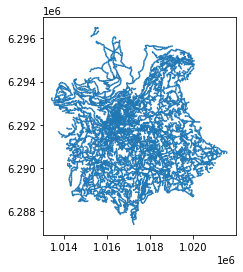

In [56]:
gdf.plot()

In [57]:
gdf.columns

Index(['lineID', 'uid', 'geometry', 'aires', 'anne', 'antoine', 'chateauneuf',
       'claude', 'françois', 'jacques', 'jean', 'magagnosc', 'mathieu', 'plan',
       'plascassier'],
      dtype='object')

In [58]:
gdf['lineID'] = gdf['lineID'].astype(int)

In [59]:
lst = ['INTERSECT', 'lineID', 'uid', 'geometry']

In [60]:
#create list of edges for support and core

list_edges_by_support = {}
list_edges_by_core = {}

aires
>> Size of subgraph by toponym ==  294
oooooooooo
>> Size of Subgraph after operations of DILATATION ==  408
aaaaaaaaaaaaaaaaa
>> Size of subgraph after operations of EROSION ==  315
tttttttttttttttttt
Size of all components from Subgraph  ==  [315]
Len of Subgraph after the extraction of the first cc ==  315
tootjrjrkh
Minimum of quantile value ==  0.2709355561912938
-- Len of subset ==  43
-- Len of Selected Edges in G ==  43
>> Size of Subgraph after operations of DILATATION ==  101
>> Size of subgraph after operations of EROSION ==  65
Size of all components from Subgraph  ==  [65]
Len of Subgraph after the extraction of the first cc ==  65
_____________________
ATTENTION == Le noyau est composé de composantes connexes : [65]
-- Len of list of edges ==  428
-- Len of list of edges ==  80
anne
>> Size of subgraph by toponym ==  245
oooooooooo
>> Size of Subgraph after operations of DILATATION ==  299
aaaaaaaaaaaaaaaaa
>> Size of subgraph after operations of EROSION ==  159
ttt

-- Len of Selected Edges in G ==  212
>> Size of Subgraph after operations of DILATATION ==  335
>> Size of subgraph after operations of EROSION ==  239
Size of all components from Subgraph  ==  [239]
Len of Subgraph after the extraction of the first cc ==  239
_____________________
ATTENTION == Le noyau est composé de composantes connexes : [239]
-- Len of list of edges ==  489
-- Len of list of edges ==  279
plascassier
>> Size of subgraph by toponym ==  540
oooooooooo
>> Size of Subgraph after operations of DILATATION ==  626
aaaaaaaaaaaaaaaaa
>> Size of subgraph after operations of EROSION ==  371
tttttttttttttttttt
Size of all components from Subgraph  ==  [371]
Len of Subgraph after the extraction of the first cc ==  371
tootjrjrkh
-- Len of subset ==  306
-- Len of Selected Edges in G ==  306
>> Size of Subgraph after operations of DILATATION ==  375
>> Size of subgraph after operations of EROSION ==  292
Size of all components from Subgraph  ==  [292]
Len of Subgraph after the 

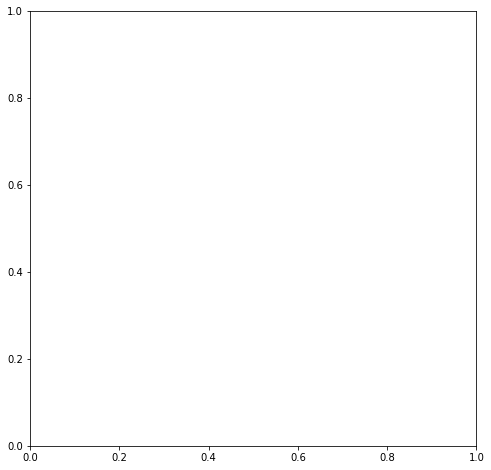

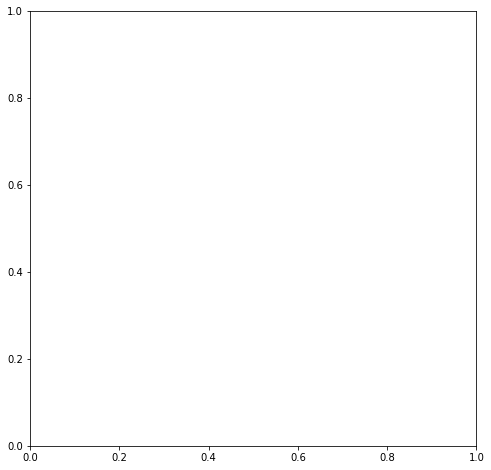

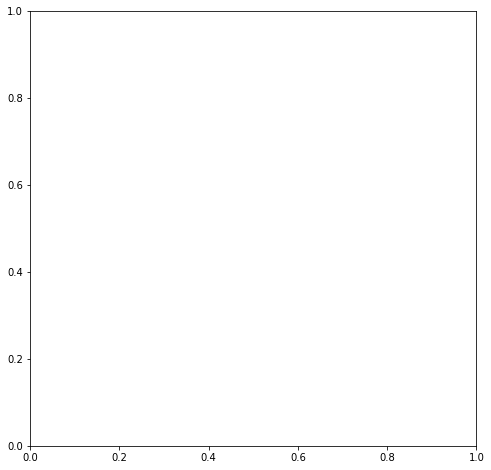

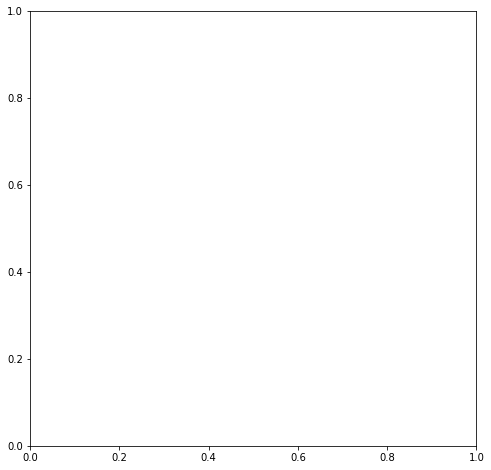

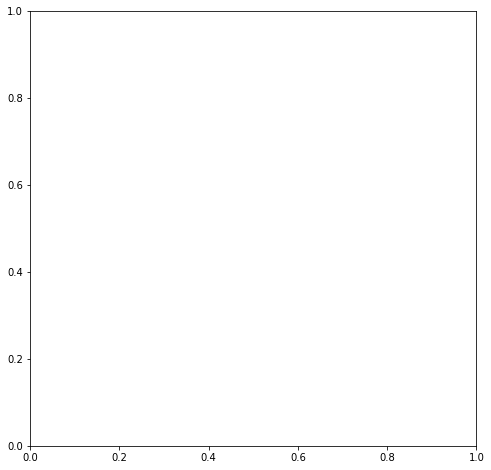

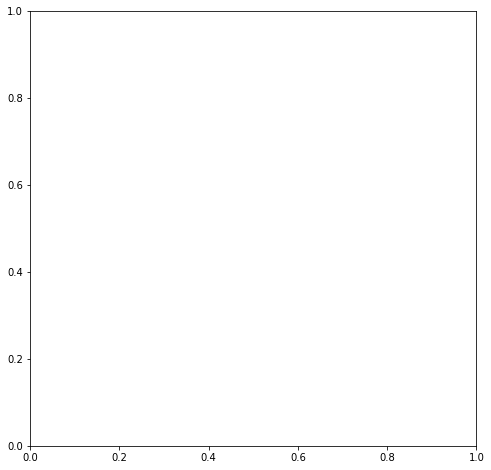

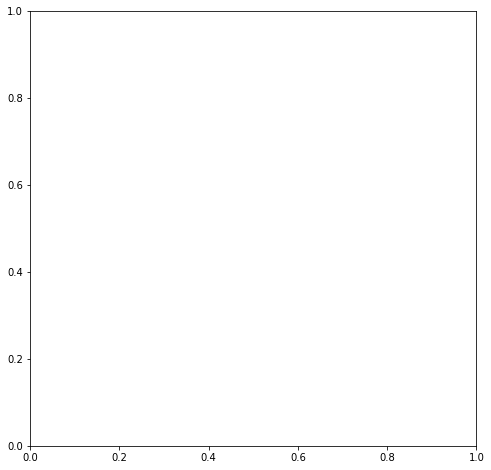

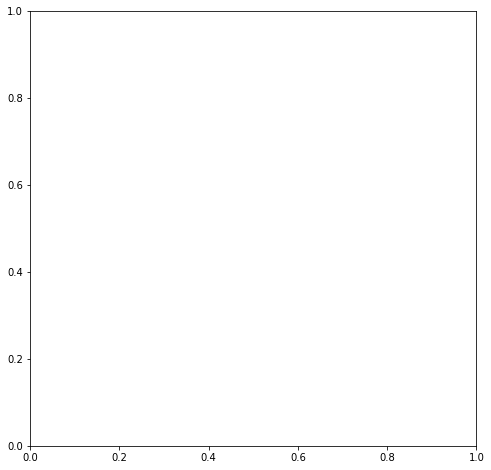

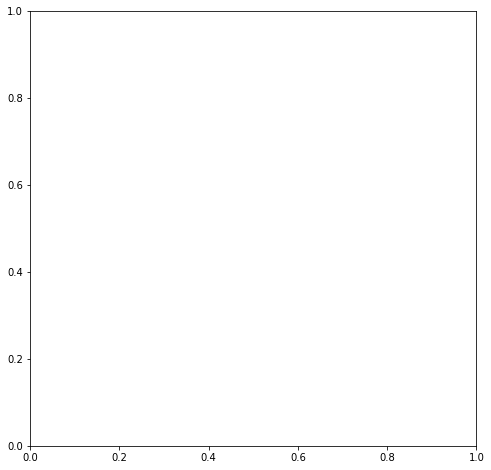

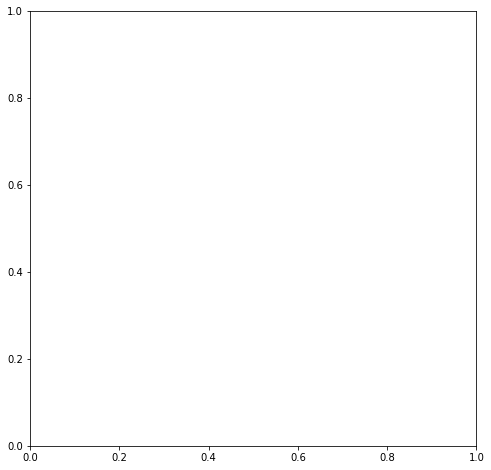

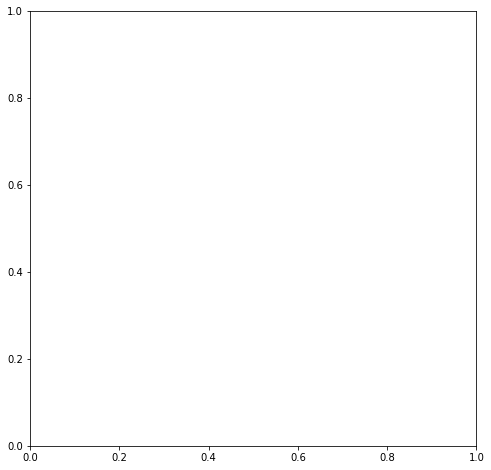

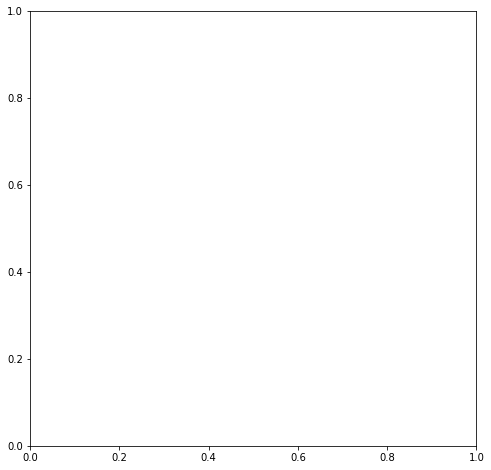

In [61]:
for col in gdf.columns:
    if col not in lst:
        try:
            TOPONYME = str(col)
            print(TOPONYME)
            applying_functions(TOPONYME, 3)
        except:
            pass


In [62]:
len(list_edges_by_core)

12

In [63]:
len(list_edges_by_support)

12

In [64]:
list_edges_by_support2 = {}
for k, v in list_edges_by_support.items():
    v_int = [int(x) for x in v]  # Convertit chaque élément de la liste en entier
    list_edges_by_support2[k] = v_int

print(list_edges_by_support2)

list_edges_by_core2 = {}
for k, v in list_edges_by_core.items():
    v_int = [int(x) for x in v]  # Convertit chaque élément de la liste en entier
    list_edges_by_core2[k] = v_int

print(list_edges_by_core2)

{'aires': [6175, 6177, 6178, 6228, 6698, 6700, 6703, 6711, 6715, 6716, 6717, 6718, 6719, 6721, 6722, 6724, 6733, 6739, 6740, 6741, 6743, 6745, 6746, 6747, 6748, 6753, 6859, 6860, 6863, 6864, 6867, 6868, 6869, 6871, 6872, 6873, 6874, 6875, 6876, 6878, 6883, 6886, 6887, 6889, 6890, 6891, 6892, 6897, 6898, 6899, 6901, 6903, 6904, 6917, 6919, 6923, 6929, 6933, 6939, 6949, 6950, 6952, 6953, 6964, 6965, 6976, 6978, 6979, 6980, 6981, 6982, 6983, 6984, 6985, 5123, 5124, 5133, 5135, 5136, 5137, 5138, 5140, 5141, 5142, 5144, 5145, 5150, 7203, 7206, 5160, 5163, 5165, 5166, 5167, 5168, 7227, 7228, 5179, 5182, 7231, 5184, 5185, 7238, 5194, 7242, 5201, 5202, 5207, 7256, 7257, 7258, 7259, 7260, 5213, 5214, 5215, 5217, 5218, 5221, 5226, 5227, 7277, 5231, 5234, 5236, 7285, 7288, 5241, 7289, 7291, 5243, 5242, 7294, 5247, 5248, 7297, 7298, 7299, 7292, 7301, 5255, 5256, 7306, 7307, 5262, 5263, 5264, 5265, 7318, 5272, 5273, 5274, 5278, 5279, 5285, 5286, 5289, 5298, 5299, 5300, 5301, 5305, 5315, 5321, 5323,

In [65]:
# Création du Geodataframe de résultats
result_gdf = gdf[['lineID', 'geometry']]
result_gdf

,lineID,geometry
0,1,"LINESTRING (1016261.000 6295759.400, 1016256.5..."
1,2,"LINESTRING (1016240.614 6295855.900, 1016241.8..."
2,3,"LINESTRING (1016256.891 6295951.903, 1016256.0..."
3,4,"LINESTRING (1016541.000 6294262.600, 1016545.7..."
4,5,"LINESTRING (1016595.191 6294179.235, 1016603.7..."
...,...,...
7936,7937,"LINESTRING (1020627.040 6290119.559, 1020632.0..."
7937,7938,"LINESTRING (1020681.512 6290200.187, 1020721.3..."
7938,7939,"LINESTRING (1020858.600 6290381.000, 1020855.8..."
7939,7940,"LINESTRING (1020708.500 6290401.600, 1020710.8..."


In [66]:
# Initialise le GeoDataFrame vide
gdf_all_support = gpd.GeoDataFrame()


for toponyme, idx_list in list_edges_by_support2.items():
    # Extraction des rues correspondantes dans le Geodataframe
    streets = result_gdf.loc[result_gdf['lineID'].isin(idx_list)]
    
    #Create un graph, merged lines, and create buffer of line
    G = momepy.gdf_to_nx(streets, approach='primal')
    G_geom = [G.edges[edge]['geometry'] for edge in G.edges]
    Geomerge = shapely.ops.linemerge(G_geom)
    my_buffer = Geomerge.buffer(5) 
    
    # Création d'un nouveau Geodataframe pour stocker la nouvelle entité
    new_gdf_support = gpd.GeoDataFrame({'toponyme': [toponyme], 'geometry': [my_buffer]}, crs=streets.crs)
    # Ajouter le nouveau GeoDataFrame à l'ensemble des GeoDataFrames
    gdf_all_support = pd.concat([gdf_all_support, new_gdf_support])

In [67]:
# Initialise le GeoDataFrame vide
gdf_all_core = gpd.GeoDataFrame()


for toponyme, idx_list in list_edges_by_core2.items():
    # Extraction des rues correspondantes dans le Geodataframe
    streets = result_gdf.loc[result_gdf['lineID'].isin(idx_list)]
    
    #Créer un graph, merged lines, and create buffer of line
    G = momepy.gdf_to_nx(streets, approach='primal')
    G_geom = [G.edges[edge]['geometry'] for edge in G.edges]
    Geomerge = shapely.ops.linemerge(G_geom)
    my_buffer = Geomerge.buffer(5) 
    
    # Création d'un nouveau Geodataframe pour stocker la nouvelle entité
    new_gdf_core = gpd.GeoDataFrame({'toponyme': [toponyme], 'geometry': [my_buffer]}, crs=streets.crs)
    # Ajouter le nouveau GeoDataFrame à l'ensemble des GeoDataFrames
    gdf_all_core = pd.concat([gdf_all_core, new_gdf_core])

In [68]:
with fiona.Env(OSR_WKT_FORMAT="WKT2_2018"):
    gdf_all_core.to_file("C:/GIT/2022/TOPONOMASCAPE/VILLE/"+VILLE+"/CORE.shp")
with fiona.Env(OSR_WKT_FORMAT="WKT2_2018"):
    gdf_all_support.to_file("C:/GIT/2022/TOPONOMASCAPE/VILLE/"+VILLE+"/SUPPORT.shp")

with open("C:/GIT/2022/TOPONOMASCAPE/VILLE/"+VILLE+"/SUPPORT.pickle", "wb") as f:
    pickle.dump(gdf_all_support, f)
with open("C:/GIT/2022/TOPONOMASCAPE/VILLE/"+VILLE+"/CORE.pickle", "wb") as f:
    pickle.dump(gdf_all_core, f)

In [ ]:
with open("C:/GIT/2022/TOPONOMASCAPE/VILLE/"+VILLE+"/list_edges_by_support_cannes.pickle", "wb") as f:
    pickle.dump(list_edges_by_support2, f)

with open("C:/GIT/2022/TOPONOMASCAPE/VILLE/"+VILLE+"/list_edges_by_core_cannes.pickle", "wb") as f:
    pickle.dump(list_edges_by_core2, f)
    
with open("C:/GIT/2022/TOPONOMASCAPE/VILLE/"+VILLE+"/gdf_all_support_cannes.pickle", "wb") as f:
    pickle.dump(list_edges_by_support, f)

with open("C:/GIT/2022/TOPONOMASCAPE/VILLE/"+VILLE+"/gdf_all_core_cannes.pickle", "wb") as f:
    pickle.dump(list_edges_by_core, f)